<a href="https://colab.research.google.com/github/penajuanmanuel6-hub/automated-etl-pipeline/blob/main/evaluacion_impacto_ambiental_biodiversidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Resumen de Afectación por Grupo Taxonómico y Amenaza ---
  grupo_taxonomico grado_amenaza  total_especies  promedio_afectacion_pct
0        Mamíferos          Baja               7                    69.57
1            Flora          Alta               5                    64.42
2        Mamíferos       Crítica               3                    63.03
3             Aves         Media               9                    60.97
4     Herpetofauna          Alta               6                    60.45
5             Aves          Baja              17                    56.29
6            Flora          Baja              23                    56.17
7     Herpetofauna         Media              12                    56.17
8        Mamíferos         Media              13                    55.58
9        Mamíferos          Alta               9                    52.98


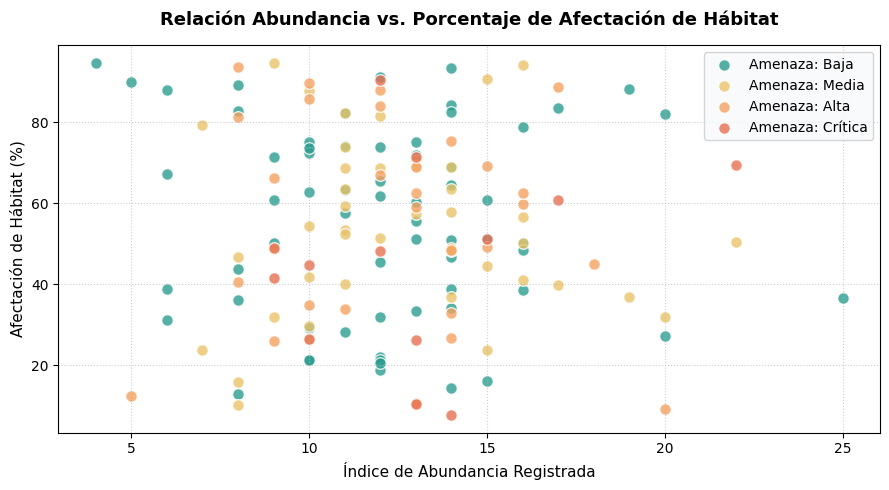

In [1]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 1. CONFIGURACIÓN Y CONEXIÓN
# ==========================================
DB_NAME = "biodiversidad_bosque_seco.db"


def crear_conexion():
  """Establece y retorna la conexión a la base de datos SQLite."""
  return sqlite3.connect(DB_NAME)


# ==========================================
# 2. EXTRACCIÓN (Simulación de matrices ecológicas)
# ==========================================
def extraer_datos_biodiversidad():
  """Genera y extrae los registros de fauna, flora y grado de amenaza."""
  np.random.seed(100)
  n_especies = 150
  taxa = ["Aves", "Mamíferos", "Herpetofauna", "Flora"]

  df_biodiversidad = pd.DataFrame(
      {
          "especie_id": [f"SP_{i:03d}" for i in range(n_especies)],
          "grupo_taxonomico": np.random.choice(taxa, n_especies),
          "indice_abundancia": np.random.poisson(lam=12, size=n_especies),
          "grado_amenaza": np.random.choice(
              ["Baja", "Media", "Alta", "Crítica"],
              n_especies,
              p=[0.4, 0.3, 0.2, 0.1],
          ),
          "afectacion_habitat_pct": np.random.uniform(
              5.0, 95.0, n_especies
          ).round(1),
      }
  )

  conn = crear_conexion()
  df_biodiversidad.to_sql(
      "registros_fauna_flora", conn, if_exists="replace", index=False
  )
  conn.close()
  return df_biodiversidad


# ==========================================
# 3. TRANSFORMACIÓN Y CARGA (Análisis SQL)
# ==========================================
def transformar_y_consultar_eco():
  """Ejecuta agregaciones y consultas analíticas sobre los datos ecológicos."""
  conn = crear_conexion()
  query = """
        SELECT
            grupo_taxonomico,
            grado_amenaza,
            COUNT(especie_id) AS total_especies,
            ROUND(AVG(afectacion_habitat_pct), 2) AS promedio_afectacion_pct
        FROM registros_fauna_flora
        GROUP BY grupo_taxonomico, grado_amenaza
        ORDER BY promedio_afectacion_pct DESC;
    """
  df_resumen = pd.read_sql(query, conn)
  conn.close()
  return df_resumen


# ==========================================
# 4. VISUALIZACIÓN DE RESULTADOS
# ==========================================
def visualizar_biodiversidad(df_bruto):
  """Genera un gráfico de dispersión relacionando abundancia y afectación."""
  fig, ax = plt.subplots(figsize=(9, 5))
  colores = {
      "Baja": "#2a9d8f",
      "Media": "#e9c46a",
      "Alta": "#f4a261",
      "Crítica": "#e76f51",
  }

  for amenaza, color in colores.items():
    subset = df_bruto[df_bruto["grado_amenaza"] == amenaza]
    ax.scatter(
        subset["indice_abundancia"],
        subset["afectacion_habitat_pct"],
        label=f"Amenaza: {amenaza}",
        color=color,
        s=70,
        alpha=0.8,
        edgecolors="w",
    )

  ax.set_title(
      "Relación Abundancia vs. Porcentaje de Afectación de Hábitat",
      fontsize=13,
      fontweight="bold",
      pad=15,
  )
  ax.set_xlabel("Índice de Abundancia Registrada", fontsize=11)
  ax.set_ylabel("Afectación de Hábitat (%)", fontsize=11)
  ax.legend(frameon=True, facecolor="#f8f9fa")
  ax.grid(True, linestyle=":", alpha=0.6)

  plt.tight_layout()
  plt.show()


# Ejecución del pipeline completo
df_original = extraer_datos_biodiversidad()
df_resumen_eco = transformar_y_consultar_eco()
print("--- Resumen de Afectación por Grupo Taxonómico y Amenaza ---")
print(df_resumen_eco.head(10))
visualizar_biodiversidad(df_original)